MACHINE LEARNINGGGGGGGGGGGGGGGGGGGGG

a lil more feature engg first

In [1]:
import pandas as pd 
import numpy as np 
import xgboost

In [2]:
df = pd.read_csv("master_dataset_fixed.csv")

In [3]:
df = df.sort_values(['driverId','year','round'])
df['driver_momentum'] = df.groupby('driverId')['driver_form'].diff()
df['driver_momentum'] = df['driver_momentum'].fillna(0)

df['constructor_momentum'] = df.groupby('constructorId')['constructor_final_position'].diff()
df['constructor_momentum'] = df['constructor_momentum'].fillna(0)

In [4]:
df['driver_circuit_specialist_score'] = (df['driver_circuit_performance_5'] * 0.7 + df['driver_circuit_experience'] * -0.3)
df['driver_circuit_specialist_score'] = df['driver_circuit_specialist_score'].fillna(0)

#qualifying performance relative to the team
df['team_avg_quali'] = df.groupby('constructorId')['qualifying_position'].transform('mean')
df['driver_quali_strength'] = df['team_avg_quali'] - df['qualifying_position']
df['driver_quali_strength'] = df['driver_quali_strength'].fillna(0)

#race pace relative to the constructor
df['constructor_avg_lap'] = df.groupby('constructorId')['avg_lap_time'].transform('mean')
df['rel_race_pace'] = df['constructor_avg_lap'] - df['avg_lap_time']
df['rel_race_pace'] = df['rel_race_pace'].fillna(0)


In [5]:
df['driver_performance_index'] = ( df['driver_form'] * 0.4 + df['qualifying_position'] * 0.3 + df['avg_lap_time'] * 0.2 + df['driver_consistency_std'] * 0.1)
df['driver_performance_index'] = df['driver_performance_index'].fillna(0)
df.to_csv("master_dataset_fixed.csv", index=False)

Model Building using XGBoost rest of the structure is similar to logistic regression 

In [6]:
df = pd.read_csv("master_dataset_fixed.csv")

df['win_flag'] = (df['final_position']==1).astype(int)
non_numeric = df.select_dtypes(include=['object']).columns.tolist()
leakage_cols = [ 'final_position', 'positionText', 'points', 'wins']
X = df.drop(columns=non_numeric + leakage_cols + ['win_flag'] + ['avg_lap_time'] + ['driver_consistency_std'] + ['driver_circuit_performance']+['lap_times'], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce')
y = df['win_flag'].astype(int)
print(df['win_flag'].value_counts())
feature_columns = X.columns.tolist()
   

win_flag
0    2429
1     149
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [9]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 500, learning_rate=0.01, max_depth=4, subsample= 0.6, colsample_bytree = 0.6, objective= 'binary:logistic', eval_metric = 'logloss', random_state=42, scale_pos_weight=16.3)
xgb.fit(X_train_imp, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [10]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = xgb.predict(X_test_imp)
y_proba = xgb.predict_proba(X_test_imp)[:, 1]
threshold = 0.65
y_pred_threshold = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred_threshold))

Accuracy: 0.939922480620155
ROC-AUC: 0.9385459533607681
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       486
           1       0.49      0.70      0.58        30

    accuracy                           0.94       516
   macro avg       0.73      0.83      0.77       516
weighted avg       0.95      0.94      0.94       516



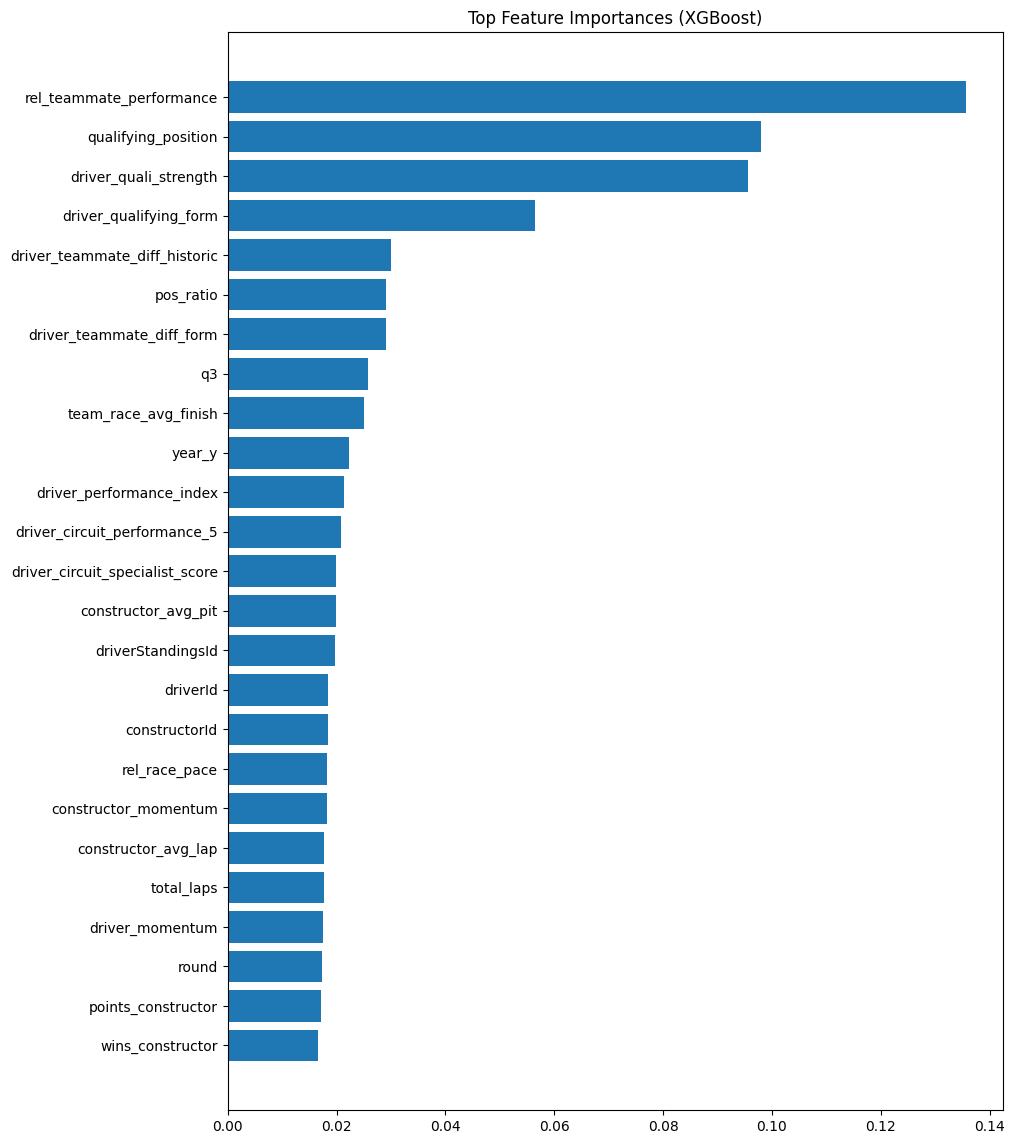

In [11]:
import matplotlib.pyplot as plt
import numpy as np

feature_importance = xgb.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 14))
plt.barh(X.columns[sorted_idx][:25], feature_importance[sorted_idx][:25])
plt.title("Top Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

In [12]:
def predict_race_winner_xgb(race_Id, df, model, imputer, feature_columns):
    race_df = df[df['raceId'] == race_Id].copy()
    if race_df.empty:
        print(f"No such raceId found.")
        return None
    X_race = race_df[feature_columns].apply(pd.to_numeric, errors='coerce')
    X_race_imp = imputer.transform(X_race)
    race_df['win_probability'] = model.predict_proba(X_race_imp)[:, 1]  
    race_df['predicted_rank'] = race_df['win_probability'].rank(ascending=False)
    race_df = race_df.sort_values('win_probability', ascending=False)
    actual_row = race_df[race_df['final_position'] == 1]
    actual_winner = actual_row.iloc[0]['driver_name'] if not actual_row.empty else None
    predicted_winner = race_df.iloc[0]['driver_name']
    if_prediction_correct = "Yes" if actual_winner == predicted_winner else "No"
    podium = race_df.head(3)[['race_name', 'year', 'driver_name', 'win_probability']]
    return race_df, actual_winner, predicted_winner, if_prediction_correct, podium


In [13]:
feature_columns = X.columns.tolist()
race_df, actual_winner, predicted_winner, if_prediction_correct, podium = predict_race_winner_xgb(race_Id=1088, df=df, model=xgb, imputer=imputer, feature_columns=feature_columns)
print(f"Actual Winner: {actual_winner}")
print(f"Podium Predictions:")
display(podium)
print()
print(f"Predicted Winner: {predicted_winner}")
print(f"Is our prediction correct? {if_prediction_correct}")


Actual Winner: Max Verstappen
Podium Predictions:


,race_name,year,driver_name,win_probability
1142,Dutch Grand Prix,2022,Max Verstappen,0.971877
1851,Dutch Grand Prix,2022,Charles Leclerc,0.636609
1277,Dutch Grand Prix,2022,Carlos Sainz,0.346753



Predicted Winner: Max Verstappen
Is our prediction correct? Yes


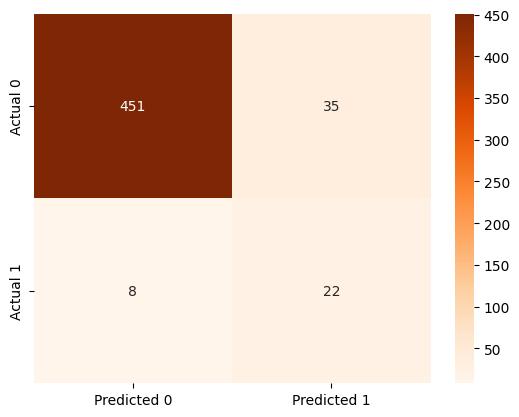

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.show()


### BAZ PORTION


Following the instructions taught by Ms. mobin's slides in class, the following testing has been conducted

In [15]:


import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, log_loss, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

#uper se features copy huwe 
X_full = df[feature_columns].apply(pd.to_numeric, errors='coerce')
y_full = df['win_flag'].astype(int)

# 90/10 split
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X_full, y_full, test_size=0.10, random_state=42, stratify=y_full
)

imp_90 = SimpleImputer(strategy='mean')
X_train_90_imp = imp_90.fit_transform(X_train_90)
X_test_10_imp = imp_90.transform(X_test_10)

# XGBoost parameters 
params = {
    'objective': 'binary:logistic',
    'eval_metric': ['logloss','auc'],
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'seed': 42,
    'scale_pos_weight': 16.3
}

dtrain = xgb.DMatrix(X_train_90_imp, label=y_train_90)

# Cross-validation on training data using the documetnation from the webstei tthat qutb sent me 
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=400,
    nfold=5,
    stratified=True,
    early_stopping_rounds=25,
    verbose_eval=False
)
best_round = len(cv_results)  # last row after early stopping

print(f"Best boosting round (CV): {best_round}")

# Train final model on training data using best_round
final_model = xgb.train(params, dtrain, num_boost_round=best_round)

# untouched testdata eval
dtest = xgb.DMatrix(X_test_10_imp)
proba_test = final_model.predict(dtest)
preds_test = (proba_test >= 0.5).astype(int)

mse = mean_squared_error(y_test_10, proba_test)
mae = mean_absolute_error(y_test_10, proba_test)
acc = accuracy_score(y_test_10, preds_test)
logloss_val = log_loss(y_test_10, proba_test)
roc_auc = roc_auc_score(y_test_10, proba_test)

print("Test Metrics (90/10 split):")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"LogLoss: {logloss_val:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Best boosting round (CV): 34
Test Metrics (90/10 split):
MSE: 0.0662
MAE: 0.1880
Accuracy: 0.9264
LogLoss: 0.2502
ROC-AUC: 0.9525


The results show that the model performs *extremely well* given the ROC-AUC being >0.95, and the MSE being extremely low. The CV Boost applied from XGboost shows that the model only required 33 adjustments and reached peak performance. The low logloss also demonstrates the high confidence in the model, showing that it isn't just reliance on guesswork but is confident in its decisions.

### Simple CV Performance Plot
Shows training CV logloss and AUC over boosting rounds (from training only).

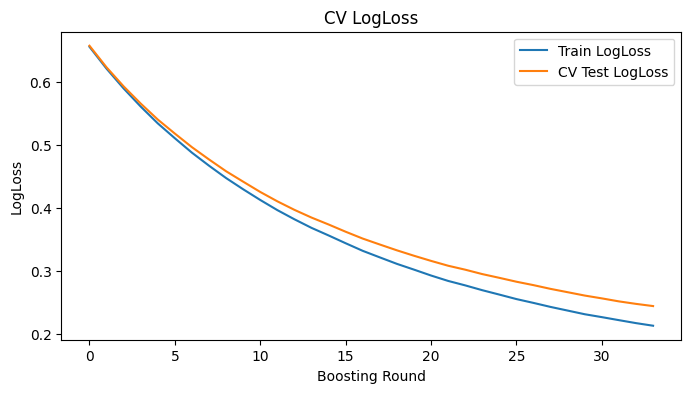

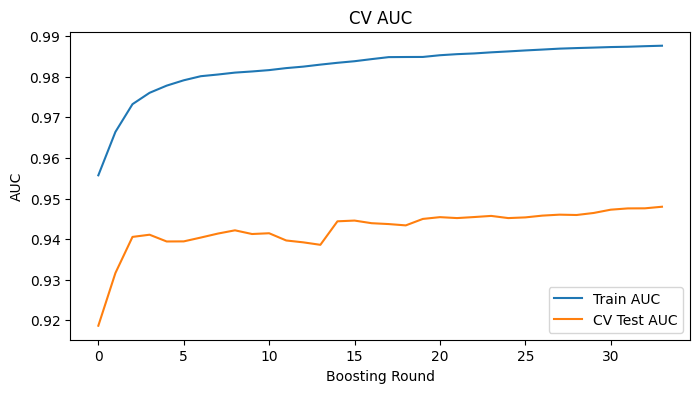

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(cv_results['train-logloss-mean'], label='Train LogLoss')
plt.plot(cv_results['test-logloss-mean'], label='CV Test LogLoss')
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.title('CV LogLoss')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(cv_results['train-auc-mean'], label='Train AUC')
plt.plot(cv_results['test-auc-mean'], label='CV Test AUC')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('CV AUC')
plt.legend()
plt.show()

### Test Set Probability Diagnostics
Simple view: histogram & ROC curve from final model on test split.

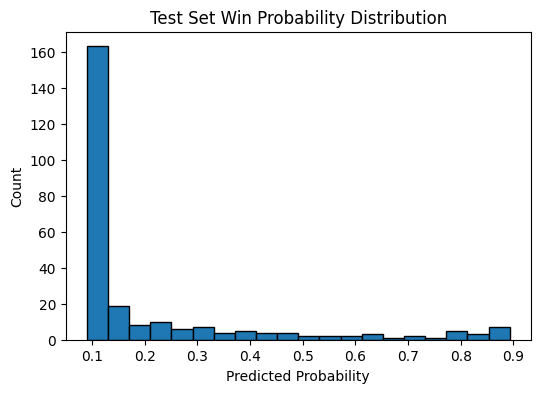

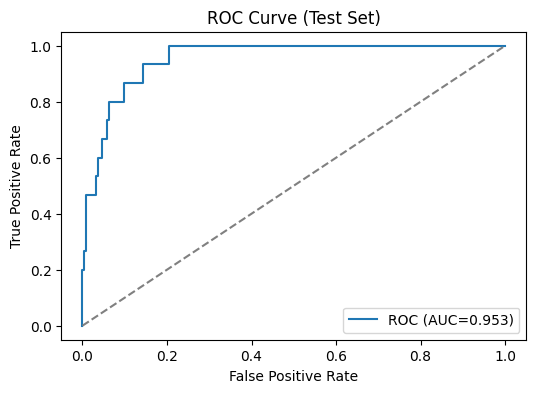

In [17]:
# Histogram and ROC curve for test probabilities
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,4))
plt.hist(proba_test, bins=20, edgecolor='black')
plt.title('Test Set Win Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.show()

fpr, tpr, _ = roc_curve(y_test_10, proba_test)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.show()

Performance is very strong; verify no leakage (e.g. variables too close to outcome like qualifying_position, constructor_final_position).
High AUC + low logloss suggests both ranking and probabilistic confidence